In [25]:
!pip install --upgrade pip setuptools
!pip install -q transformers torch pyvi pandas matplotlib peft
!pip install -q scikit-learn

In [26]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Categorical
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from pyvi import ViTokenizer
from sklearn.metrics import f1_score
from peft import LoraConfig, get_peft_model

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/ABSA_Task2'
DATA_DIR = '/content/task2_dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# ==========================================
# CELL 2: CẤU HÌNH SIÊU THAM SỐ PPO
# ==========================================
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS_PPO = 3        # Số epoch quét qua toàn bộ dataset
PPO_EPOCHS_K = 4      # Số lần tối ưu trên cùng 1 batch (K)
LEARNING_RATE = 1e-5  # LR thấp hơn SFT
CLIP_EPSILON = 0.2    # epsilon
C1_VALUE = 0.5        # Hệ số Value Loss
C2_ENTROPY = 0.01     # Hệ số Entropy Bonus
C3_KL = 0.1           # Hệ số KL Penalty
ALPHA_REWARD = 0.7    # Hệ số trộn Reward F1

MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ASPECT_COLS = [
    "FACILITIES#CLEANLINESS", "FACILITIES#COMFORT", "FACILITIES#DESIGN&FEATURES", "FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS", "FACILITIES#PRICES", "FACILITIES#QUALITY", "FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES", "FOOD&DRINKS#QUALITY", "FOOD&DRINKS#STYLE&OPTIONS", "HOTEL#CLEANLINESS",
    "HOTEL#COMFORT", "HOTEL#DESIGN&FEATURES", "HOTEL#GENERAL", "HOTEL#MISCELLANEOUS", "HOTEL#PRICES",
    "HOTEL#QUALITY", "LOCATION#GENERAL", "ROOMS#CLEANLINESS", "ROOMS#COMFORT", "ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL", "ROOMS#MISCELLANEOUS", "ROOMS#PRICES", "ROOMS#QUALITY", "ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT", "ROOM_AMENITIES#DESIGN&FEATURES", "ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS", "ROOM_AMENITIES#PRICES", "ROOM_AMENITIES#QUALITY", "SERVICE#GENERAL"
]

In [28]:
# ==========================================
# CELL 3: DATALOADER
# ==========================================
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.texts = df['Review'].values
        self.labels = df[ASPECT_COLS].values

    def __len__(self):
        return len(self.df)

    def preprocess(self, text):
        return ViTokenizer.tokenize(str(text).lower())

    def __getitem__(self, index):
        text = self.preprocess(self.texts[index])
        labels = self.labels[index]
        encoding = self.tokenizer(
            text, truncation=True, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# The DATA_DIR variable was incorrectly set in a previous cell.
# The actual path to the dataset is in Google Drive.
# Fixing the path directly here to ensure the CSV file is found.
train_df = pd.read_csv(f"/content/drive/MyDrive/task2_dataset/1-VLSP2018-SA-Hotel-train.csv")
train_loader = DataLoader(ABSADataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)

In [29]:
# ==========================================
# CELL 4: KIẾN TRÚC MÔ HÌNH ACTOR-CRITIC
# ==========================================

# Fix: Upgrade torchao to a compatible version for peft
!pip install --upgrade torchao

class PhoBertACSA_ActorCritic(nn.Module):
    def __init__(self, n_aspects, n_polarities):
        super(PhoBertACSA_ActorCritic, self).__init__()
        phobert = AutoModel.from_pretrained(MODEL_NAME)
        lora_config = LoraConfig(
            r=8, lora_alpha=16, target_modules=["query", "value"], lora_dropout=0.1, bias="none"
        )
        self.phobert = get_peft_model(phobert, lora_config)
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, n_aspects * n_polarities)
        self.critic = nn.Linear(self.phobert.config.hidden_size, n_aspects)
        self.n_aspects = n_aspects
        self.n_polarities = n_polarities

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)

        logits = self.classifier(pooled_output)
        values = self.critic(pooled_output)

        return logits.view(-1, self.n_aspects, self.n_polarities), values

# Khởi tạo Active Model (Mô hình đang học)
model = PhoBertACSA_ActorCritic(len(ASPECT_COLS), 4).to(DEVICE)
model.load_state_dict(torch.load(f"{SAVE_PATH}/actor_critic_pretrained.bin"))

# Khởi tạo Reference Model (Đóng băng hoàn toàn)
model_ref = PhoBertACSA_ActorCritic(len(ASPECT_COLS), 4).to(DEVICE)
model_ref.load_state_dict(torch.load(f"{SAVE_PATH}/actor_critic_pretrained.bin"))
model_ref.eval()
for param in model_ref.parameters():
    param.requires_grad = False

# Chỉ Active Model mới được cập nhật gradients
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
# ==========================================
# CELL 5: HÀM TÍNH TOÁN PPO TOÁN HỌC
# ==========================================
def compute_rewards(actions, labels):
    """Tính reward: Lớp thiểu số (+2), Lớp đa số (+1), None (+0.1), Sai (-1)"""
    rewards = torch.full_like(labels, -1.0, dtype=torch.float).to(DEVICE)
    mask_correct = (actions == labels)
    rewards[mask_correct & ((labels == 2) | (labels == 3))] = 2.0
    rewards[mask_correct & (labels == 1)] = 1.0
    rewards[mask_correct & (labels == 0)] = 0.1
    return rewards

def get_batch_f1_macro(actions, labels):
    y_true = labels.cpu().numpy().flatten()
    y_pred = actions.cpu().numpy().flatten()
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def compute_kl_divergence(logits, ref_logits):
    """Tính KL Divergence giữa policy hiện tại và policy gốc"""
    probs = F.softmax(logits, dim=-1)
    ref_probs = F.softmax(ref_logits, dim=-1)
    kl = F.kl_div(F.log_softmax(logits, dim=-1), ref_probs, reduction='none').sum(dim=-1)
    return kl

In [31]:
# ==========================================
# CELL 6: VÒNG LẶP HUẤN LUYỆN PPO CHÍNH
# ==========================================
history = {'ppo_loss': [], 'reward': [], 'f1_macro': []}

for epoch in range(EPOCHS_PPO):
    print(f"\n--- Bắt đầu PPO Epoch {epoch+1}/{EPOCHS_PPO} ---")

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        # 1. ROLLOUT: Lấy dữ liệu từ Active Model và Reference Model (No Gradient)
        with torch.no_grad():
            logits_old, values_old = model(input_ids, attention_mask)
            logits_ref, _ = model_ref(input_ids, attention_mask)

            # Lấy mẫu hành động (Action) từ phân phối xác suất
            dist_old = Categorical(logits=logits_old)
            actions = dist_old.sample()
            log_probs_old = dist_old.log_prob(actions)

            # Tính Step Reward
            step_rewards = compute_rewards(actions, labels)

            # Tính Batch F1 Reward
            batch_f1 = get_batch_f1_macro(actions, labels)

            # Trộn Reward theo công thức: r_F1 = alpha * r(s,a) + (1-alpha) * F1_macro
            total_rewards = ALPHA_REWARD * step_rewards + (1 - ALPHA_REWARD) * batch_f1

            # Tính Advantage = Reward - Value dự đoán của Critic
            advantages = total_rewards - values_old

            # Chuẩn hóa Advantage (Advantage Normalization) để ổn định PPO
            adv_mean = advantages.mean()
            adv_std = advantages.std() + 1e-8
            advantages = (advantages - adv_mean) / adv_std

        # 2. OPTIMIZATION: Lặp K lần trên cùng 1 batch
        batch_ppo_loss = 0
        for _ in range(PPO_EPOCHS_K):
            model.train()
            optimizer.zero_grad()

            logits_new, values_new = model(input_ids, attention_mask)
            dist_new = Categorical(logits=logits_new)

            # Log prob mới và Tỷ lệ r_t
            log_probs_new = dist_new.log_prob(actions)
            ratio = torch.exp(log_probs_new - log_probs_old)

            # A. L^CLIP (Clipped Surrogate Objective)
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPSILON, 1.0 + CLIP_EPSILON) * advantages
            policy_loss = -torch.min(surr1, surr2).mean()

            # B. L^VF (Value Function Loss - MSE)
            value_loss = F.mse_loss(values_new, total_rewards)

            # C. H (Entropy Bonus)
            entropy = dist_new.entropy().mean()

            # D. KL Penalty
            kl_div = compute_kl_divergence(logits_new, logits_ref).mean()

            # TỔNG LOSS L_total
            loss = policy_loss + C1_VALUE * value_loss - C2_ENTROPY * entropy + C3_KL * kl_div

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_ppo_loss += loss.item()

        # Log Metrics
        avg_reward = total_rewards.mean().item()
        history['ppo_loss'].append(batch_ppo_loss / PPO_EPOCHS_K)
        history['reward'].append(avg_reward)
        history['f1_macro'].append(batch_f1)

        if step % 20 == 0:
            print(f"Step {step} | PPO Loss: {batch_ppo_loss/PPO_EPOCHS_K:.4f} | Avg Reward: {avg_reward:.4f} | F1-Macro: {batch_f1:.4f} | KL: {kl_div.item():.4f}")

# Lưu mô hình hoàn thiện
torch.save(model.state_dict(), f"{SAVE_PATH}/final_ppo_model.bin")
print(">> Đã hoàn thành Giai đoạn 3 và lưu final_ppo_model.bin")


--- Bắt đầu PPO Epoch 1/3 ---
Step 0 | PPO Loss: 0.1429 | Avg Reward: -0.1814 | F1-Macro: 0.2677 | KL: 0.0124
Step 20 | PPO Loss: 0.1238 | Avg Reward: -0.1645 | F1-Macro: 0.2686 | KL: 0.0188
Step 40 | PPO Loss: 0.1146 | Avg Reward: -0.1280 | F1-Macro: 0.2785 | KL: 0.0443
Step 60 | PPO Loss: 0.0996 | Avg Reward: -0.1107 | F1-Macro: 0.2792 | KL: 0.0924
Step 80 | PPO Loss: 0.1068 | Avg Reward: -0.0656 | F1-Macro: 0.2914 | KL: 0.1418
Step 100 | PPO Loss: 0.1412 | Avg Reward: -0.0023 | F1-Macro: 0.3603 | KL: 0.2023
Step 120 | PPO Loss: 0.1246 | Avg Reward: -0.0353 | F1-Macro: 0.3077 | KL: 0.2658
Step 140 | PPO Loss: 0.1187 | Avg Reward: -0.0002 | F1-Macro: 0.3269 | KL: 0.3222
Step 160 | PPO Loss: 0.1113 | Avg Reward: 0.0152 | F1-Macro: 0.3223 | KL: 0.3405
Step 180 | PPO Loss: 0.1184 | Avg Reward: 0.0387 | F1-Macro: 0.3421 | KL: 0.3996

--- Bắt đầu PPO Epoch 2/3 ---
Step 0 | PPO Loss: 0.1148 | Avg Reward: 0.0295 | F1-Macro: 0.3155 | KL: 0.4078
Step 20 | PPO Loss: 0.1132 | Avg Reward: 0.0280

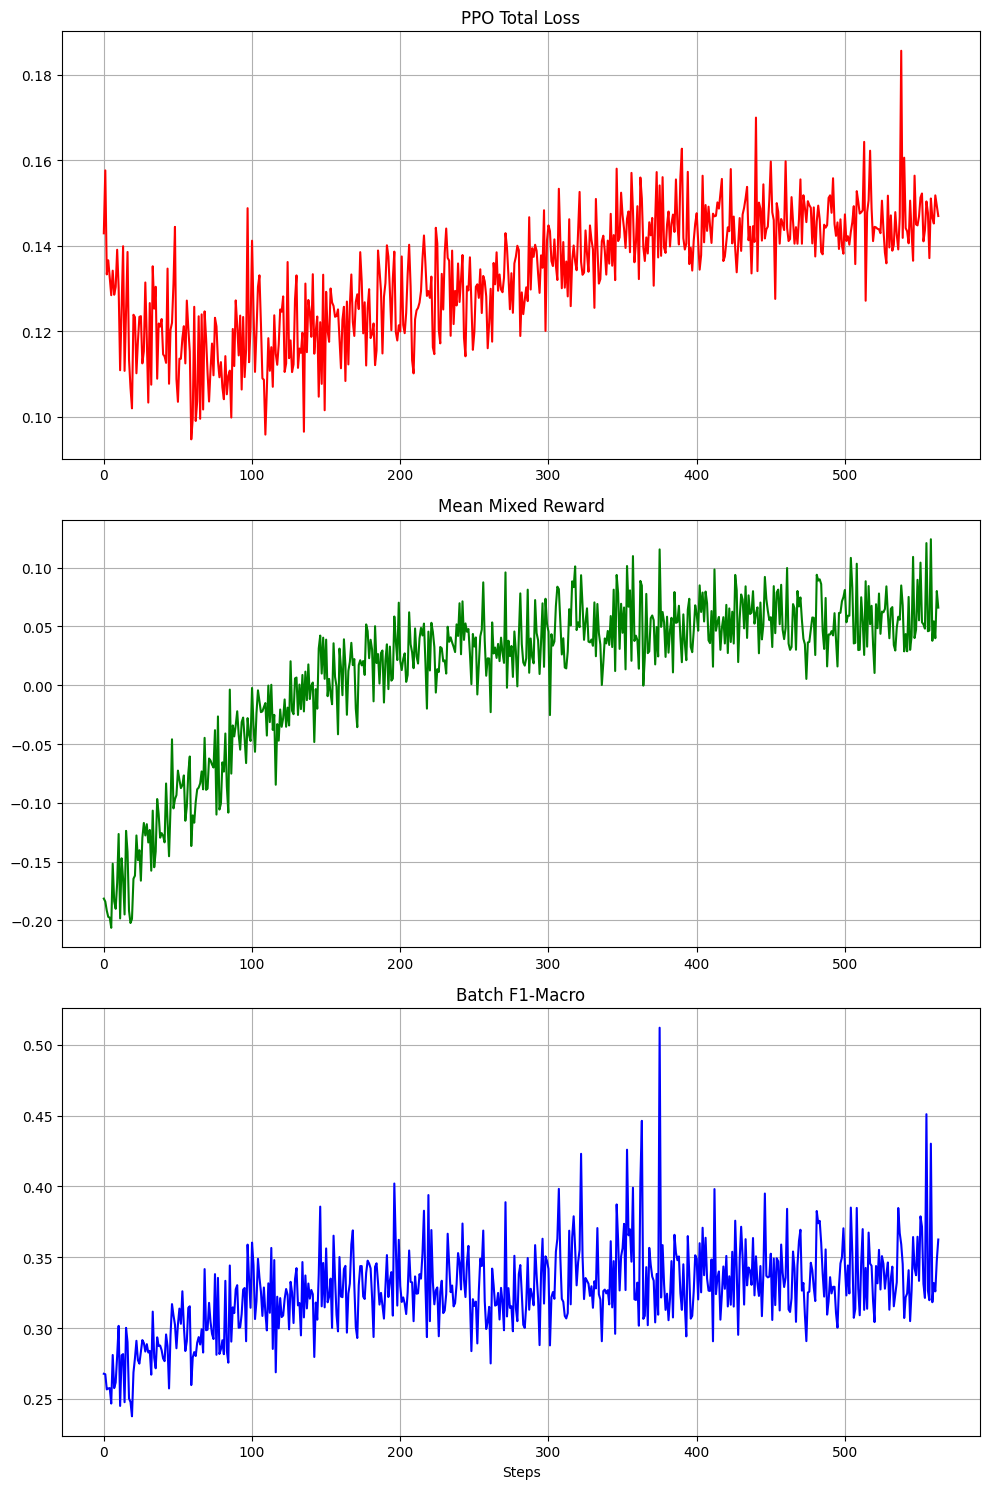

In [32]:
# ==========================================
# CELL 7: BIỂU ĐỒ THEO DÕI PPO METRICS
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

axs[0].plot(history['ppo_loss'], color='red')
axs[0].set_title('PPO Total Loss')
axs[0].grid(True)

axs[1].plot(history['reward'], color='green')
axs[1].set_title('Mean Mixed Reward')
axs[1].grid(True)

axs[2].plot(history['f1_macro'], color='blue')
axs[2].set_title('Batch F1-Macro')
axs[2].set_xlabel('Steps')
axs[2].grid(True)

plt.tight_layout()
plt.show()